# Task 1

---

## Web scraping and analysis

This Jupyter notebook includes some code to get you started with web scraping. We will use a package called `BeautifulSoup` to collect the data from the web. Once you've collected your data and saved it into a local `.csv` file you should start with your analysis.

### Scraping data from Skytrax

If you visit [https://www.airlinequality.com] you can see that there is a lot of data there. For this task, we are only interested in reviews related to British Airways and the Airline itself.

If you navigate to this link: [https://www.airlinequality.com/airline-reviews/british-airways] you will see this data. Now, we can use `Python` and `BeautifulSoup` to collect all the links to the reviews and then to collect the text data on each of the individual review links.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
base_url = "https://www.airlinequality.com/airline-reviews/british-airways"
pages = 10
page_size = 100

reviews = []

# for i in range(1, pages + 1):
for i in range(1, pages + 1):

    print(f"Scraping page {i}")

    # Create URL to collect links from paginated data
    url = f"{base_url}/page/{i}/?sortby=post_date%3ADesc&pagesize={page_size}"

    # Collect HTML data from this page
    response = requests.get(url)

    # Parse content
    content = response.content
    parsed_content = BeautifulSoup(content, 'html.parser')
    for para in parsed_content.find_all("div", {"class": "text_content"}):
        reviews.append(para.get_text())

    print(f"   ---> {len(reviews)} total reviews")

Scraping page 1
   ---> 100 total reviews
Scraping page 2
   ---> 200 total reviews
Scraping page 3
   ---> 300 total reviews
Scraping page 4
   ---> 400 total reviews
Scraping page 5
   ---> 500 total reviews
Scraping page 6
   ---> 600 total reviews
Scraping page 7
   ---> 700 total reviews
Scraping page 8
   ---> 800 total reviews
Scraping page 9
   ---> 900 total reviews
Scraping page 10
   ---> 1000 total reviews


In [ ]:
import os
print(os.listdir())

['.config', 'sample_data']


In [ ]:
df = pd.DataFrame()
df["reviews"] = reviews
df.head()

,reviews
0,✅ Trip Verified | On a recent flight from Cy...
1,✅ Trip Verified | Flight BA 0560 arrived in ...
2,✅ Trip Verified | This was the first time I ...
3,✅ Trip Verified | Pretty good flight but sti...
4,"✅ Trip Verified | Check in was fine, but no pr..."


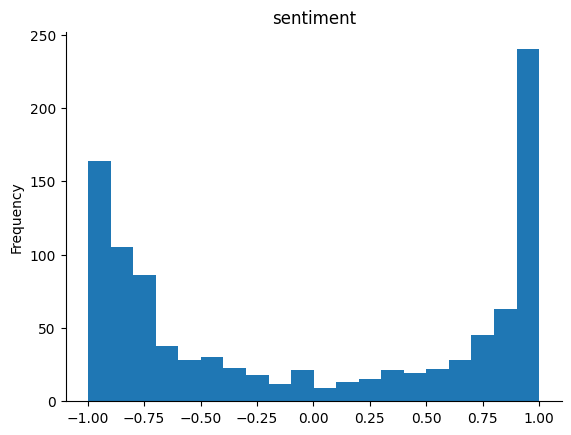

In [ ]:
# @title sentiment

from matplotlib import pyplot as plt
df['sentiment'].plot(kind='hist', bins=20, title='sentiment')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
import re
df['reviews'] = df['reviews'].str.replace(r'✅ Trip Verified \|', '', regex=True)

In [ ]:
df.head()

,reviews
0,On a recent flight from Cyprus BA621 on 23/...
1,Flight BA 0560 arrived in Rome on 11 Decemb...
2,This was the first time I flew British Airw...
3,Pretty good flight but still some small thi...
4,"Check in was fine, but no priority/fast track..."


from matplotlib import pyplot as plt
import seaborn as sns
_df_6.groupby('reviews').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
df['sentiment'] = df['reviews'].apply(lambda review: analyzer.polarity_scores(review)['compound'])

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(df['reviews'])

lda = LatentDirichletAllocation(n_components=5, random_state=42) # Adjust n_components as needed
lda.fit(tfidf)

LatentDirichletAllocation(n_components=5, random_state=42)

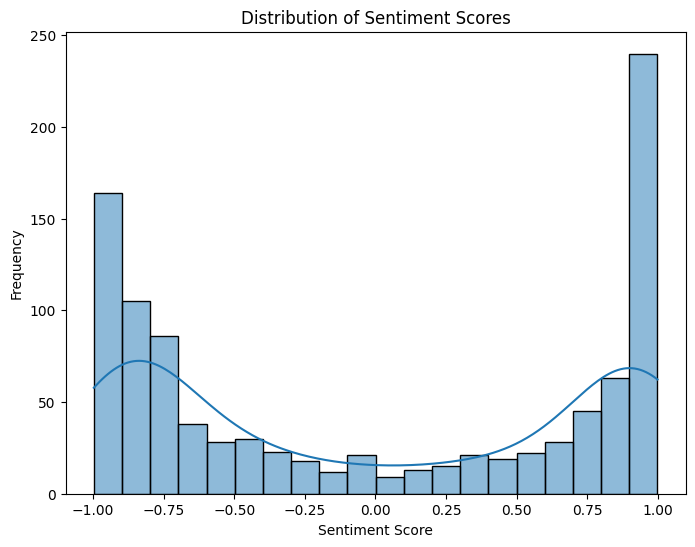

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['sentiment'], bins=20, kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

In [ ]:
sentiment_counts = df['sentiment_category'].value_counts()
plt.figure(figsize=(6, 4))
sentiment_counts.plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.show()

KeyError: 'sentiment_category'

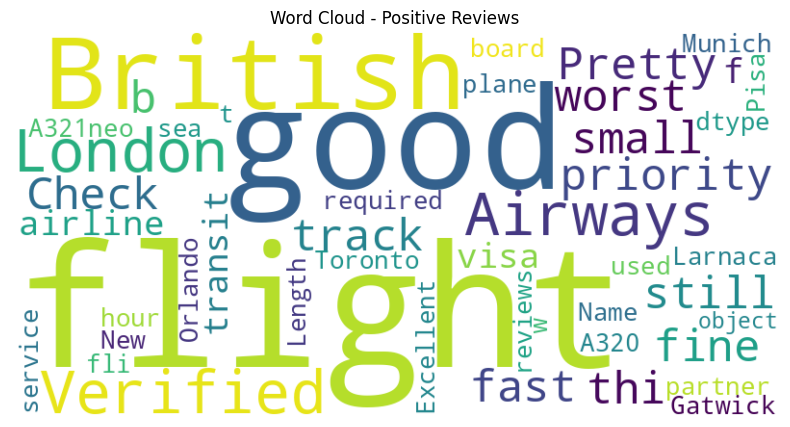

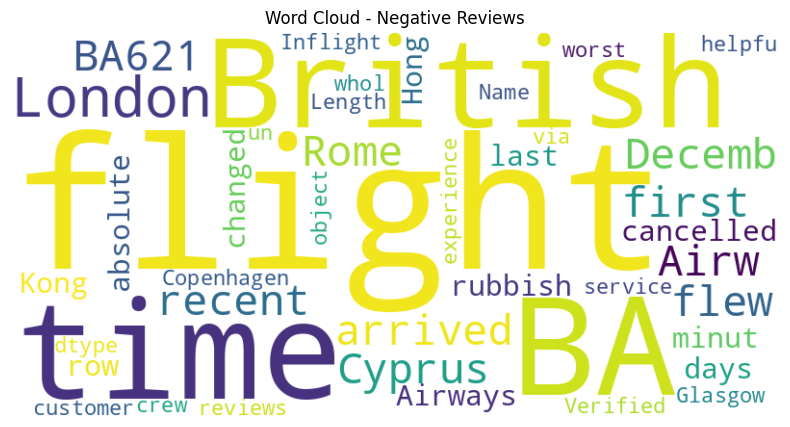

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

positive_reviews = df[df['sentiment'] > 0]['reviews']
negative_reviews = df[df['sentiment'] < 0]['reviews']

  # Create and display the word clouds
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(str(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

create_wordcloud(positive_reviews, 'Word Cloud - Positive Reviews')
create_wordcloud(negative_reviews, 'Word Cloud - Negative Reviews')

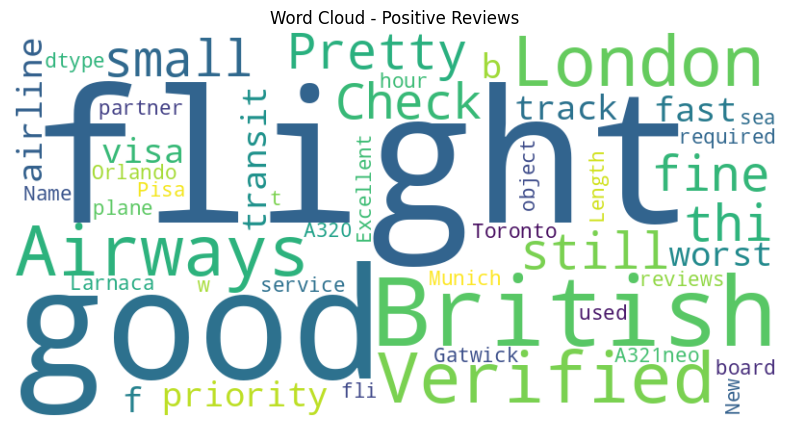

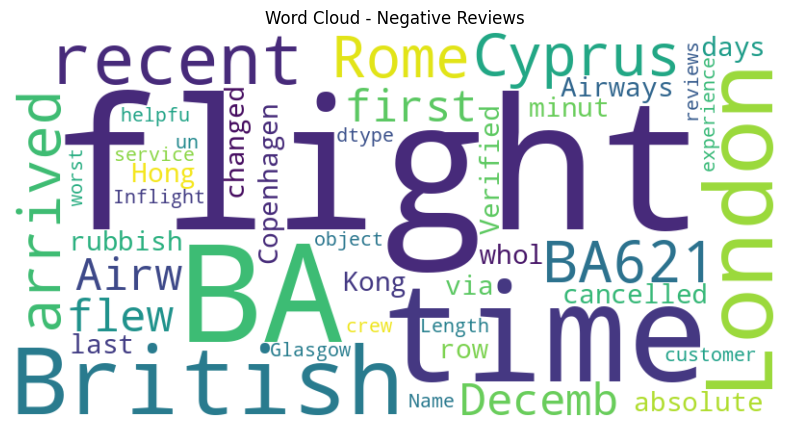

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

positive_reviews = df[df['sentiment'] > 0]['reviews']
negative_reviews = df[df['sentiment'] < 0]['reviews']

  # Create and display the word clouds
def create_wordcloud(text, title):
      wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(str(text))
      plt.figure(figsize=(10, 5))
      plt.imshow(wordcloud, interpolation='bilinear')
      plt.axis('off')
      plt.title(title)
      plt.show()

create_wordcloud(positive_reviews, 'Word Cloud - Positive Reviews')
create_wordcloud(negative_reviews, 'Word Cloud - Negative Reviews')

In [ ]:
import pyLDAvis
import pyLDAvis.sklearn

pyLDAvis.enable_notebook()
vis = pyLDAvis.sklearn.prepare(lda, tfidf, vectorizer)
vis

ModuleNotFoundError: No module named 'pyLDAvis'

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['reviews'].apply(lambda review: analyzer.polarity_scores(review)['compound'])

# Count positive and negative reviews
positive_reviews_count = df[df['sentiment_score'] > 0]['sentiment_score'].count()
negative_reviews_count = df[df['sentiment_score'] < 0]['sentiment_score'].count()

print(f"Number of positive reviews: {positive_reviews_count}")
print(f"Number of negative reviews: {negative_reviews_count}")

Number of positive reviews: 475
Number of negative reviews: 519


In [ ]:
from matplotlib import pyplot as plt
_df_4['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

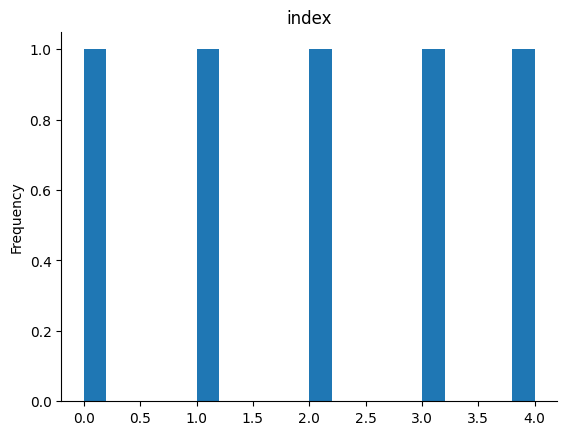

In [ ]:
from matplotlib import pyplot as plt
_df_1['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

Congratulations! Now you have your dataset for this task! The loops above collected 1000 reviews by iterating through the paginated pages on the website. However, if you want to collect more data, try increasing the number of pages!

 The next thing that you should do is clean this data to remove any unnecessary text from each of the rows. For example, "✅ Trip Verified" can be removed from each row if it exists, as it's not relevant to what we want to investigate.

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
nltk.download('vader_lexicon')
nltk.download('punkt')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
df = pd.read_csv(r"/content/BA_reviews.csv")